In [376]:
# Develop a code that run linear regression with gradient decent algorithm for each of the explanatory variables in isolation.
# In this case, you assume that in each iteration, only one explanatory variable (either X1, or X2, or X3) is explaining the output.
# Basically, you need to do three different training, one per each explanatory variable.
# For the learning rate, explore different values between 0.1 and 0.01 (your choice). Initialize your parameters to zero (theta to zero).

In [377]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [378]:
file_path = '/content/drive/MyDrive/Dataset/D3.csv'
sample = pd.read_csv(file_path)
sample.head()

,X1,X2,X3,Y
0,0.000000,3.440000,0.440000,4.387545
1,0.040404,0.134949,0.888485,2.679650
2,0.080808,0.829899,1.336970,2.968490
3,0.121212,1.524848,1.785455,3.254065
4,0.161616,2.219798,2.233939,3.536375


In [379]:
X1 = sample['X1'].values
X2 = sample['X2'].values
X3 = sample['X3'].values
Y = sample['Y'].values
X_0 = np.ones ((m, 1))
X_1 = X1.reshape(m, 1)
X_2 = X2.reshape(m, 1)
X_3 = X3.reshape(m, 1)

X1_final = np.hstack((X_0, X_1))
X2_final = np.hstack((X_0, X_2))
X3_final = np.hstack((X_0, X_3))


In [380]:
# Cost Function
def cost_function (X, Y, theta):
  m = len(Y)
  predictions = X.dot(theta)
  errors = np.subtract(predictions, Y)
  sqrErrors = np.square(errors)
  return 1/(2*m) * np.sum(sqrErrors)

# Gradient descent
def gradient_descent (X, Y, theta, alpha, iterations):
  m=len(Y)
  cost_history = np.zeros(iterations)

  for i in range(iterations):
    predictions = X.dot(theta)
    errors = np.subtract(predictions, Y)
    sum_delta = (alpha / m) * X.transpose().dot(errors);
    theta = theta - sum_delta
    cost_history[i] = cost_function(X, Y, theta)
  return theta, cost_history


In [381]:
theta = np.zeros(2)

cost1 = cost_function (X1_final, Y, theta)
# print (X1_final[:4])
print('Cost function of X1 =' ,cost1)
# print (X2_final[:4])
cost2 = cost_function (X2_final, Y, theta)
print('Cost function of X2 =' ,cost2)
# print (X3_final[:4])
cost3 = cost_function (X3_final, Y, theta)
print('Cost function of X3 =' ,cost3)



Cost function of X1 = 5.524438459196242
Cost function of X2 = 5.524438459196242
Cost function of X3 = 5.524438459196242


In [382]:
# PROBLEM 1

In [383]:
# With an alpha = 0.01, the linear model h(x)= theta(0)+theta(1)*X
# We set iteration = 1500

In [384]:
# Model using X1
alpha = 0.01
iterations = 1500
theta = np.zeros(2)

theta, cost_history1 = gradient_descent(X1_final, Y, theta, alpha, iterations)
final_cost_X1 = cost_function(X1_final, Y, theta)

print('Cost function of X1 =' ,final_cost_X1)
print('Theta of X1 =' ,theta)
print(f"Linear model for X1 is h(x) = {theta[0]} +({theta[1]})*X1")


Cost function of X1 = 0.9905894438682062
Theta of X1 = [ 5.71850653 -1.9568206 ]
Linear model for X1 is h(x) = 5.718506528385593 +(-1.9568205977732744)*X1


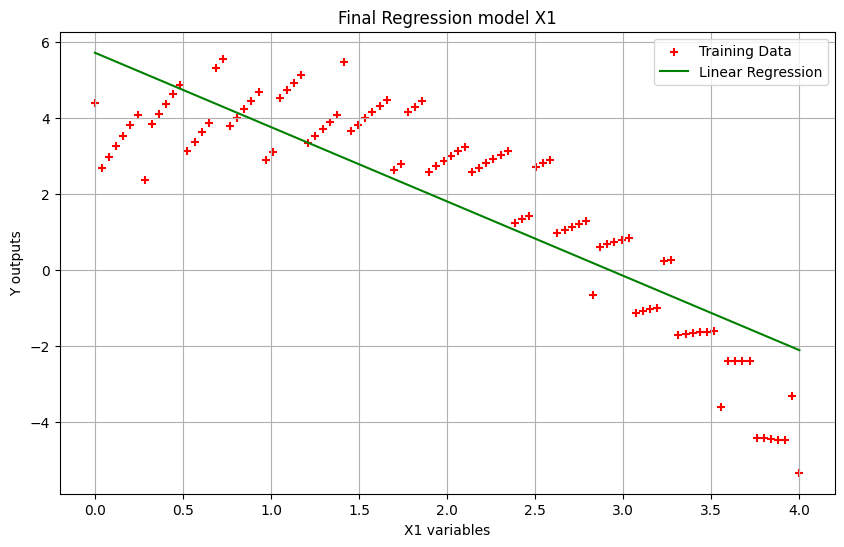

In [385]:
plt.scatter(X1, Y,color='red', marker='+', label='Training Data')

plt.plot(X1, X1_final.dot(theta), color='green', label='Linear Regression')
plt.grid(True)
plt.rcParams  ['figure.figsize'] = (10, 6)
plt.xlabel('X1 variables')
plt.ylabel('Y outputs')
plt.title('Final Regression model X1')
plt.legend()
plt.show()

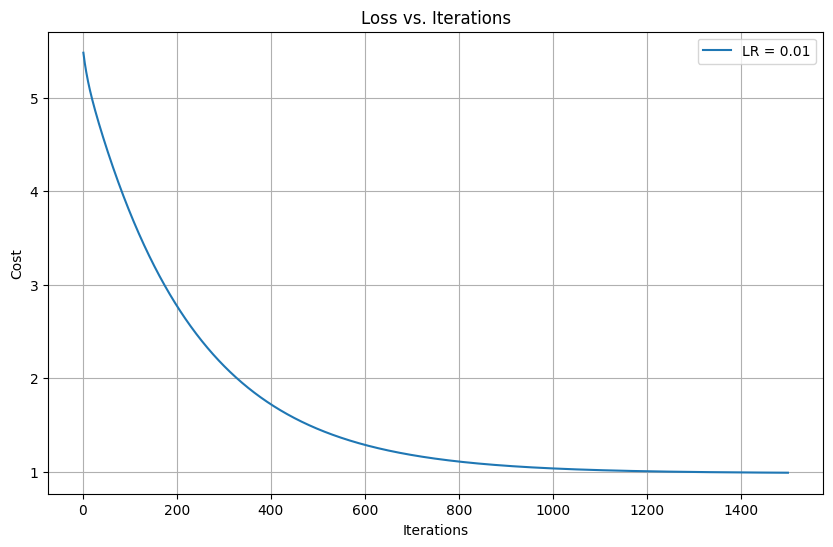

In [386]:
plt.plot(range(1, iterations + 1), cost_history1, label=f"LR = {alpha}")
plt.rcParams  ['figure.figsize'] = (10, 6)
plt.grid(True)
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Loss vs. Iterations')
plt.legend()
plt.show()

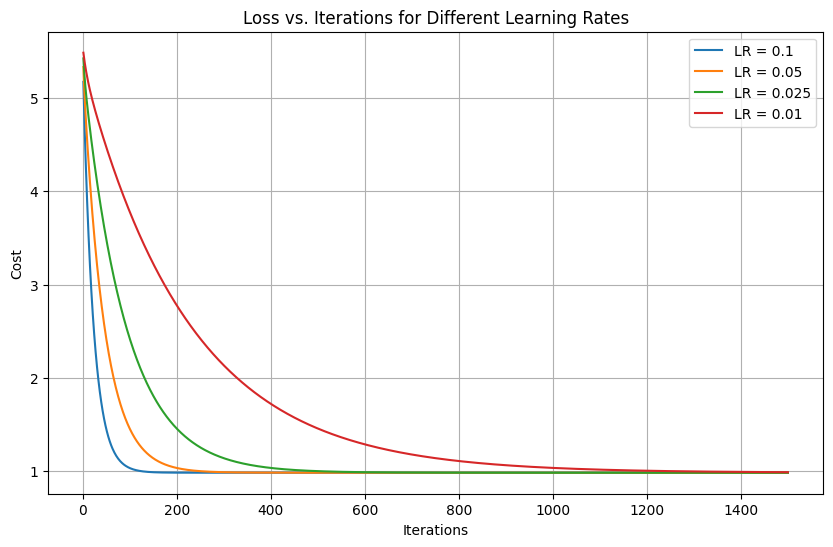

In [387]:
# Since our range of alpha is [0.1,0.01] i chose different alphas in that range a tested to see which us the best
alphas_range = [0.1, 0.05, 0.025, 0.01]
iterations = 1500

for alpha in alphas_range:
    theta = np.zeros(2)
    theta, cost_history = gradient_descent(X1_final, Y, theta, alpha, iterations)

    plt.plot(range(1, iterations + 1), cost_history, label=f"LR = {alpha}")

plt.rcParams  ['figure.figsize'] = (10, 6)
plt.grid(True)
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Loss vs. Iterations for Different Learning Rates')
plt.legend()
plt.show()


In [388]:
# Model using X2
theta2 = np.zeros(2)
alpha = 0.01
iterations = 1500

theta2, cost_history2 = gradient_descent(X2_final, Y, theta2, alpha, iterations)
final_cost_X2 = cost_function(X2_final, Y, theta)

print('Cost function of X2 =' ,final_cost_X2)
print('Theta of X2 =' ,theta2)
print(f"Linear model for X2 is h(x) = {theta2[0]} +({theta2[1]})*X2")


Cost function of X2 = 7.9002875784574735
Theta of X2 = [0.71988473 0.56390334]
Linear model for X2 is h(x) = 0.7198847334502397 +(0.5639033419472831)*X2


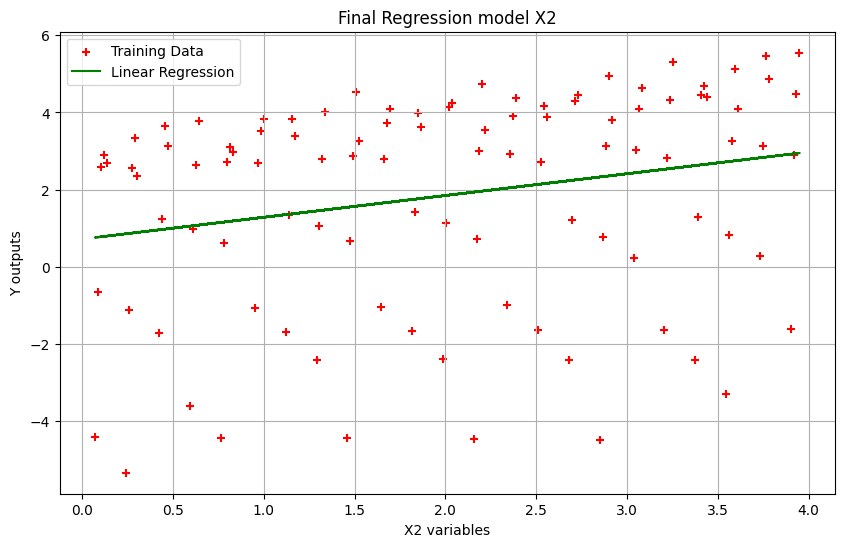

In [389]:
plt.scatter(X2, Y,color='red', marker='+', label='Training Data')
plt.plot(X2, X2_final.dot(theta2), color='green', label='Linear Regression')
plt.grid(True)
plt.rcParams  ['figure.figsize'] = (10, 6)
plt.xlabel('X2 variables')
plt.ylabel('Y outputs')
plt.title('Final Regression model X2')
plt.legend()
plt.show()

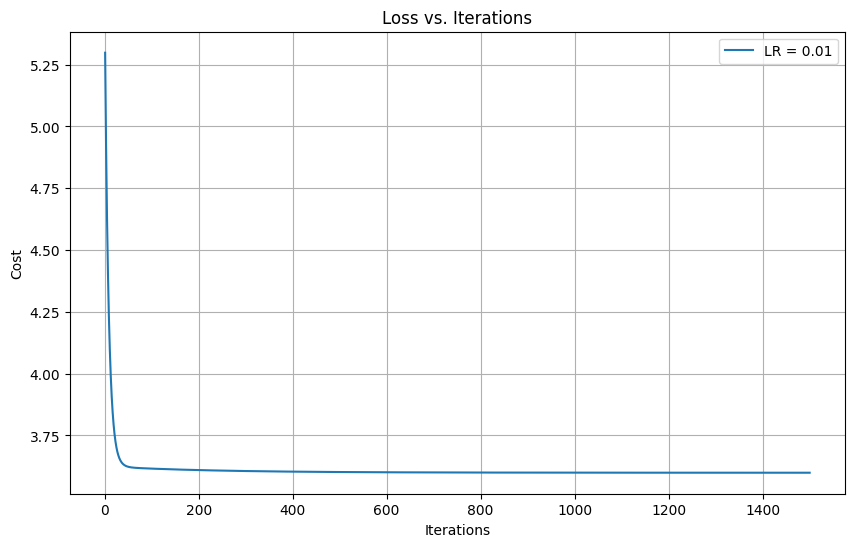

In [390]:
plt.plot(range(1, iterations + 1), cost_history2, label=f"LR = {alpha}")

plt.rcParams  ['figure.figsize'] = (10, 6)
plt.grid(True)
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Loss vs. Iterations')
plt.legend()
plt.show()

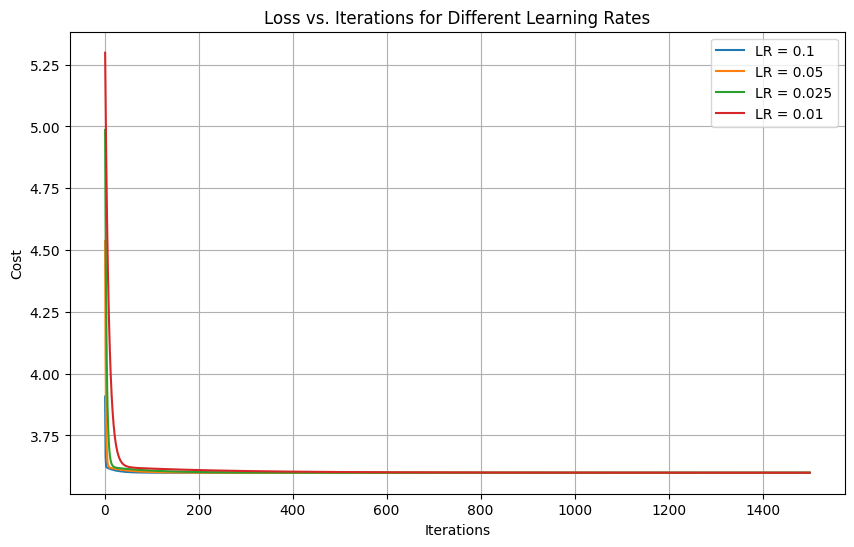

In [391]:
# Since our range of alpha is [0.1,0.01] i chose different alphas in that range a tested to see which us the best
alphas_range = [0.1, 0.05, 0.025, 0.01]
iterations = 1500

for alpha in alphas_range:
    theta2 = np.zeros(2)
    theta2, cost_history2 = gradient_descent(X2_final, Y, theta2, alpha, iterations)

    plt.plot(range(1, iterations + 1), cost_history2, label=f"LR = {alpha}")

plt.rcParams  ['figure.figsize'] = (10, 6)
plt.grid(True)
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Loss vs. Iterations for Different Learning Rates')
plt.legend()
plt.show()

In [392]:
# Model using X3
theta3 = np.zeros(2)
alpha = 0.01
iterations = 1500

theta3, cost_history3 = gradient_descent(X3_final, Y, theta3, alpha, iterations)
final_cost_X3 = cost_function(X3_final, Y, theta)

print('Cost function of X3 =' ,final_cost_X3)
print('Theta of X3 =' ,theta3)
print(f"Linear model for X3 is h(x) ={theta3[0]} +({theta3[1]})*X2")

Cost function of X3 = 5.011237704855794
Theta of X3 = [ 2.78048129 -0.48451631]
Linear model for X3 is h(x) =2.7804812909944903 +(-0.4845163094735121)*X2


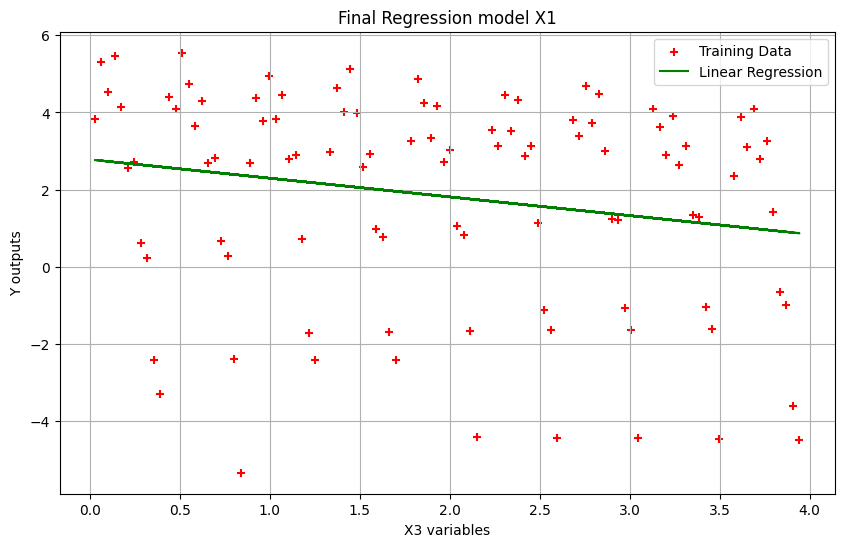

In [393]:
plt.scatter(X3, Y,color='red', marker='+', label='Training Data')
plt.plot(X3, X3_final.dot(theta3), color='green', label='Linear Regression')
plt.grid(True)
plt.rcParams  ['figure.figsize'] = (10, 6)
plt.xlabel('X3 variables')
plt.ylabel('Y outputs')
plt.title('Final Regression model X1')
plt.legend()
plt.show()

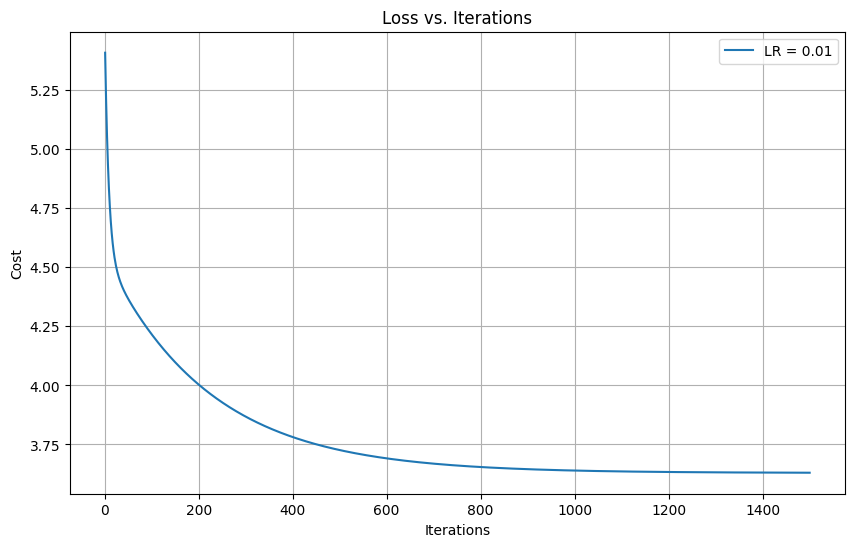

In [394]:
plt.plot(range(1, iterations + 1), cost_history3, label=f"LR = {alpha}")

plt.rcParams  ['figure.figsize'] = (10, 6)
plt.grid(True)
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Loss vs. Iterations')
plt.legend()
plt.show()

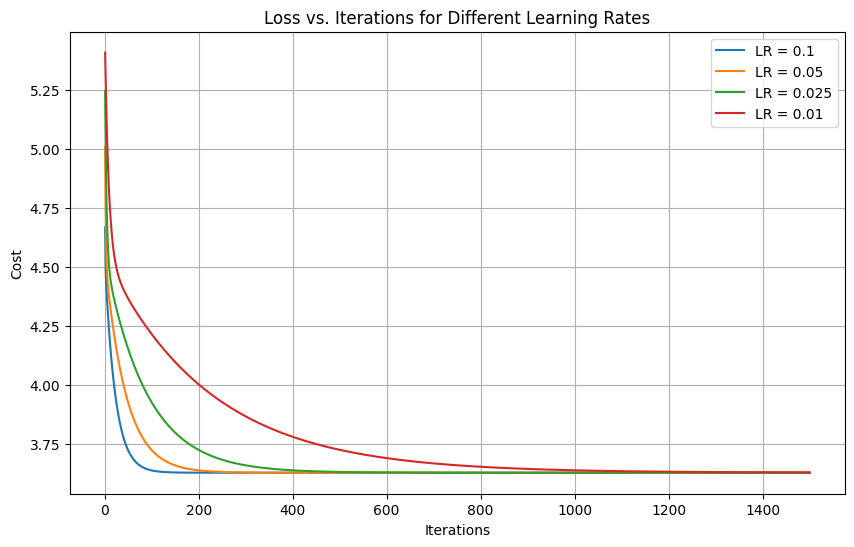

In [395]:
# Since our range of alpha is [0.1,0.01] i chose different alphas in that range a tested to see which us the best
alphas_range = [0.1, 0.05, 0.025, 0.01]
iterations = 1500

for alpha in alphas_range:
    theta3 = np.zeros(2)
    theta3, cost_history3 = gradient_descent(X3_final, Y, theta3, alpha, iterations)

    plt.plot(range(1, iterations + 1), cost_history3, label=f"LR = {alpha}")

plt.rcParams  ['figure.figsize'] = (10, 6)
plt.grid(True)
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Loss vs. Iterations for Different Learning Rates')
plt.legend()
plt.show()

In [396]:
# PROBLEM 2

In [397]:
X_finals = np.hstack((X_0, X_1, X_2, X_3))
thetas = np.zeros(4)

print(X_finals[:5])
print(X_finals.shape)
print(thetas)

[[1.         0.         3.44       0.44      ]
 [1.         0.04040404 0.1349495  0.88848485]
 [1.         0.08080808 0.82989899 1.3369697 ]
 [1.         0.12121212 1.52484848 1.78545454]
 [1.         0.16161616 2.21979798 2.23393939]]
(100, 4)
[0. 0. 0. 0.]


In [398]:
iterations = 1500

thetas, cost_historys = gradient_descent(X_finals, Y, thetas, alpha, iterations)
final_cost_Xs = cost_function(X_finals, Y, thetas)

print('Cost function of X =' ,final_cost_Xs)
print('Theta of X =' ,thetas)

print(
    f"Final linear model ŷ = {thetas[0]:.4f} "
    f"+ ({thetas[1]:.4f})X1 "
    f"+ ({thetas[2]:.4f})X2 "
    f"+ ({thetas[3]:.4f})X3"
)

Cost function of X = 0.8105104429083866
Theta of X = [ 4.15118728 -1.8394291   0.72473856 -0.09513266]
Final linear model ŷ = 4.1512 + (-1.8394)X1 + (0.7247)X2 + (-0.0951)X3


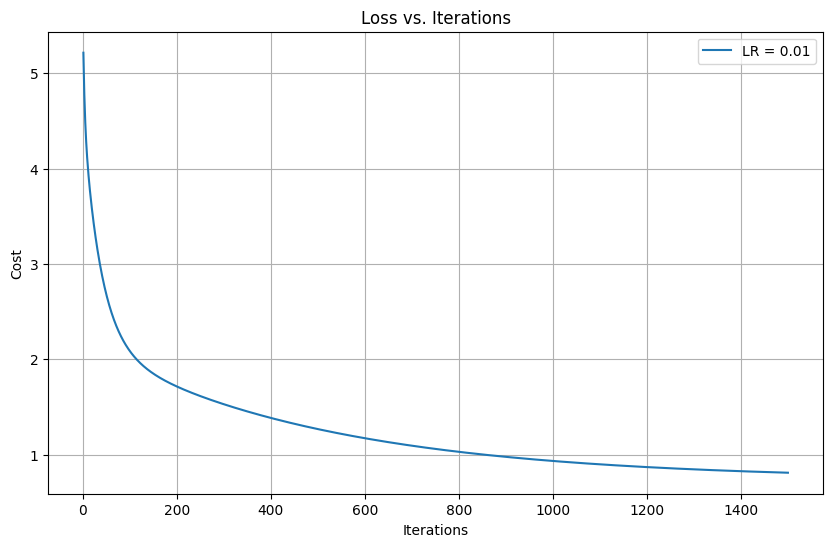

In [399]:
plt.plot(range(1, iterations + 1), cost_historys, label=f"LR = {alpha}")

plt.rcParams  ['figure.figsize'] = (10, 6)
plt.grid(True)
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Loss vs. Iterations')
plt.legend()
plt.show()

Learning Rate: 0.1
Final Cost: 0.7384642415684215
Final Theta: [ 5.31416563 -2.00371905  0.53256359 -0.26560164]
------------------------
Learning Rate: 0.05
Final Cost: 0.7384646851794184
Final Theta: [ 5.31128136 -2.0033116   0.5330402  -0.26517886]
------------------------
Learning Rate: 0.025
Final Cost: 0.7392697573699527
Final Theta: [ 5.19119589 -1.98634754  0.55288358 -0.24757678]
------------------------
Learning Rate: 0.01
Final Cost: 0.8105104429083866
Final Theta: [ 4.15118728 -1.8394291   0.72473856 -0.09513266]
------------------------


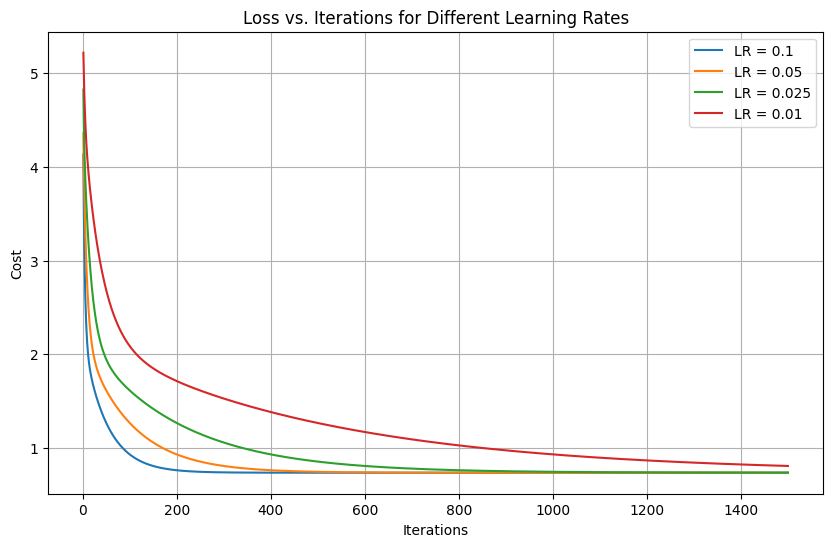

In [400]:
alphas_range = [0.1, 0.05, 0.025, 0.01]
iterations = 1500

for alpha in alphas_range:
    thetas = np.zeros(4)
    thetas, cost_historys = gradient_descent(X_finals, Y, thetas, alpha, iterations)


    plt.plot(range(1, iterations + 1), cost_historys, label=f"LR = {alpha}")

    print("Learning Rate:", alpha)
    print("Final Cost:", cost_historys[-1])
    print("Final Theta:", thetas)
    print("------------------------")

plt.rcParams  ['figure.figsize'] = (10, 6)
plt.grid(True)
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Loss vs. Iterations for Different Learning Rates')
plt.legend()
plt.show()

In [401]:
alpha = 0.025
iterations = 1500
X_new = np.array([
    [1, 1, 1, 1],
    [1, 2, 0, 4],
    [1, 3, 2, 1]
])

thetas = np.zeros(4)

thetas, cost_best = gradient_descent(X_finals,Y,thetas,alpha,iterations)

print("Best Theta:", thetas)
print("Best Final Cost:", cost_best[-1])
print("------------------------")

prediction = X_new.dot(thetas)

print("Predicted Y for (1, 1, 1):", prediction[0])
print("Predicted Y for (2, 0, 4):", prediction[1])
print("Predicted Y for (3, 2, 1):", prediction[2])

Best Theta: [ 5.19119589 -1.98634754  0.55288358 -0.24757678]
Best Final Cost: 0.7392697573699527
------------------------
Predicted Y for (1, 1, 1): 3.5101551557406827
Predicted Y for (2, 0, 4): 0.2281937111323904
Predicted Y for (3, 2, 1): 0.09034365367753239
